In [102]:
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
from scipy.ndimage import distance_transform_edt, binary_erosion

In [103]:
mri = cv2.imread('TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_11.tif', cv2.COLOR_BGR2RGB)
mask = cv2.imread('TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_11_mask.tif', cv2.COLOR_BGR2RGB)

<function matplotlib.pyplot.show(close=None, block=None)>

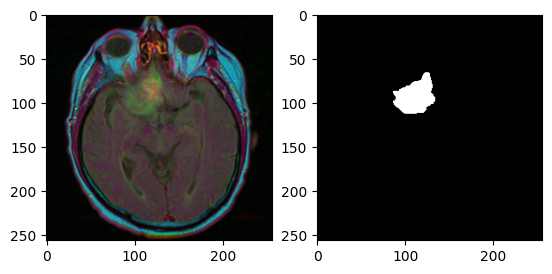

In [104]:
plt.subplot(1, 2, 1)
plt.imshow(mri)

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")

plt.show

In [105]:
print("img shape  :", mri.shape)
print("mask shape :", mask.shape)

img shape  : (256, 256, 3)
mask shape : (256, 256)


In [106]:
def mask_to_3channel(mask):
    h, w = mask.shape

    channel_0 = (mask == 0).float
    channel_1 = (mask == 1).float
    channel_1 = (mask == 2).float

In [107]:
(mask == 255).sum()

1426

In [108]:
mask = torch.tensor(mask)
mask.shape

torch.Size([256, 256])

In [109]:
mask = torch.unsqueeze(mask, 0)
mask.shape

torch.Size([1, 256, 256])

In [110]:
mask = mask.repeat(3, 1, 1)
mask.shape

torch.Size([3, 256, 256])

In [111]:
def prepare_mask(mask_input):
    # FIX: Convert Tensor to NumPy array if necessary
    if isinstance(mask_input, torch.Tensor):
        # .detach() is not strictly needed if not tracking gradients, but good practice
        # .cpu() is required if the tensor is on the GPU
        mask_np = mask_input.detach().cpu().numpy()
    else:
        mask_np = mask_input
    
    # Original logic continues
    binary = (mask_np == 255).astype(np.float32)
    
    # Use torch.from_numpy for efficiency instead of torch.tensor()
    ch0 = torch.from_numpy(binary)
    
    dist = distance_transform_edt(binary)
    # Check for division by zero if the mask is empty
    if dist.max() > 0:
        ch1 = torch.from_numpy(dist / dist.max())
    else:
        ch1 = torch.zeros_like(ch0)
    
    eroded = binary_erosion(binary, iterations=2).astype(np.float32)
    ch2 = torch.from_numpy((binary - eroded).clip(0, 1))
    
    return torch.stack([ch0, ch1, ch2], dim=0)

In [112]:
mask2 = prepare_mask(mask)

In [113]:
mask2.shape

torch.Size([3, 3, 256, 256])

In [114]:
mri.shape

(256, 256, 3)

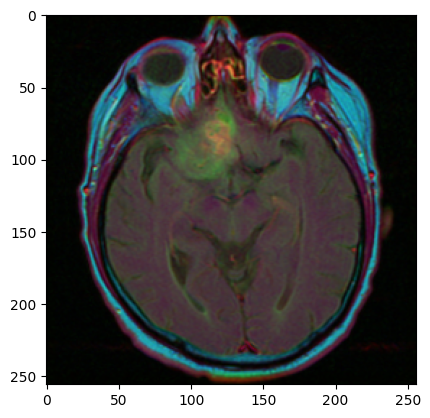

In [118]:
plt.imshow(mri)

In [116]:
mri[:, :, 0] == mri[:, :, 1]

array([[ True,  True,  True, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [ True, False, False, ...,  True,  True, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ...,  True, False,  True]])